In [13]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ADMIN\Downloads\titanic.csv\train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The dataset contains passenger information such as PassengerId, Survived, Pclass, Name, Sex, Age, Fare, and Embarked.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


The dataset contains passenger details such as age, gender, class, fare, and survival status. Some columns contain missing values, particularly Age, Cabin, and Embarked.

In [15]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


The average passenger age is around 29 years. Ticket fares vary widely, indicating different travel classes and fare categories.

In [16]:
df["Sex"].value_counts()
df["Survived"].value_counts()

0    549
1    342
Name: Survived, dtype: int64

The number of passengers who did not survive was higher than the number of passengers who survived.

In [17]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Cabin has the highest number of missing values, while Age and Embarked also contain some missing data that may require treatment before analysis.

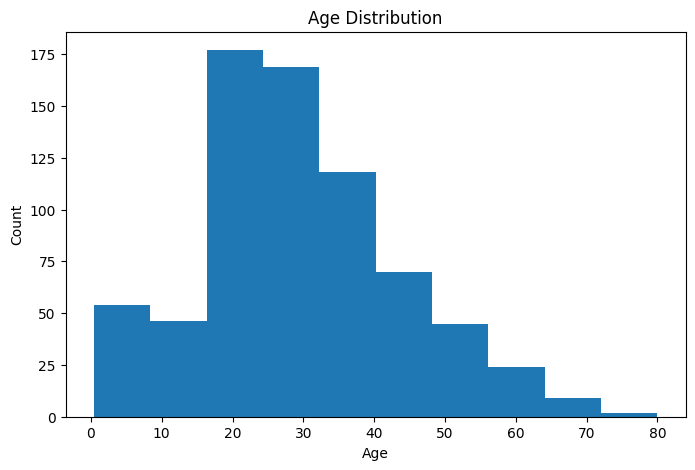

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["Age"].dropna())
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

The age distribution contains a few outliers, indicating the presence of some much older passengers.

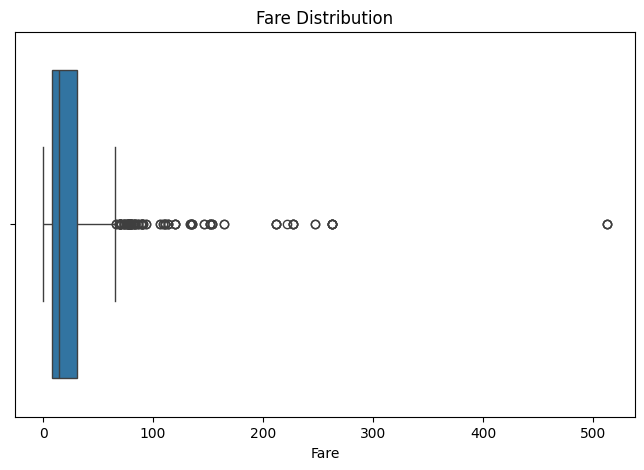

In [21]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fare"])
plt.title("Fare Distribution")
plt.show()

Several extreme fare values are present, suggesting that some passengers paid premium ticket prices.

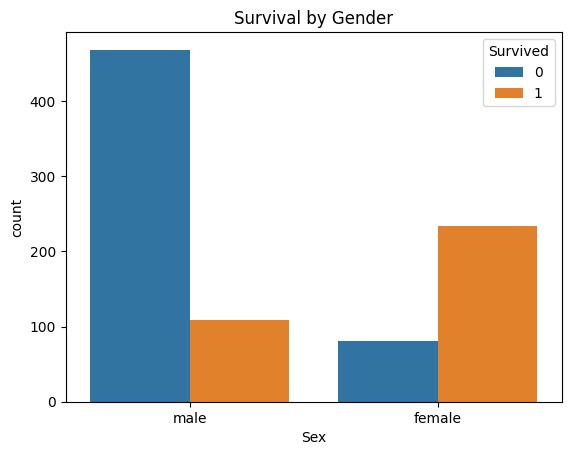

In [22]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

Male passengers were more numerous than female passengers in the dataset.
Female passengers had a significantly higher survival rate compared to male passengers.

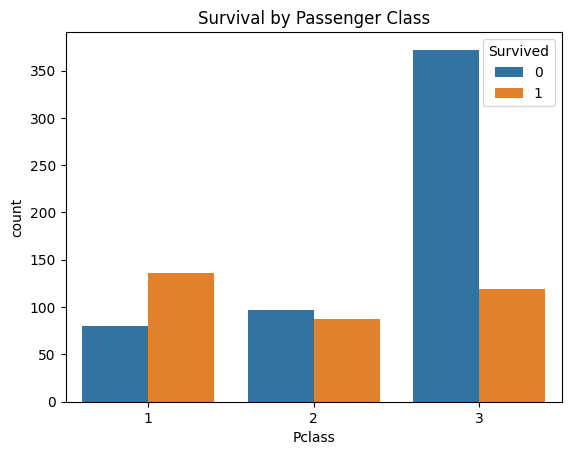

In [23]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

Passengers traveling in first class had better survival chances than those in second and third class.

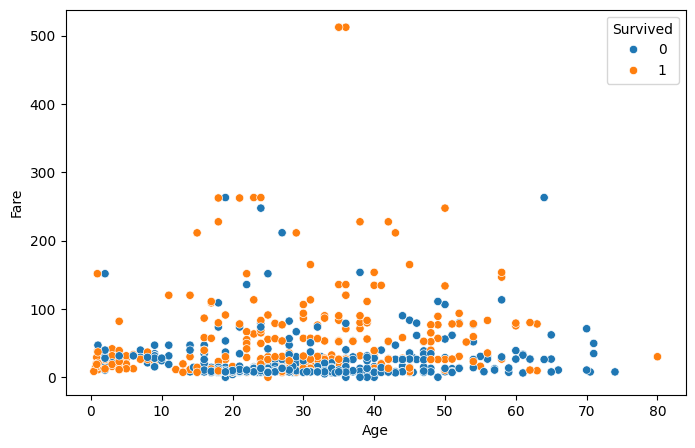

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df)
plt.show()

There is no strong relationship between passenger age and ticket fare.

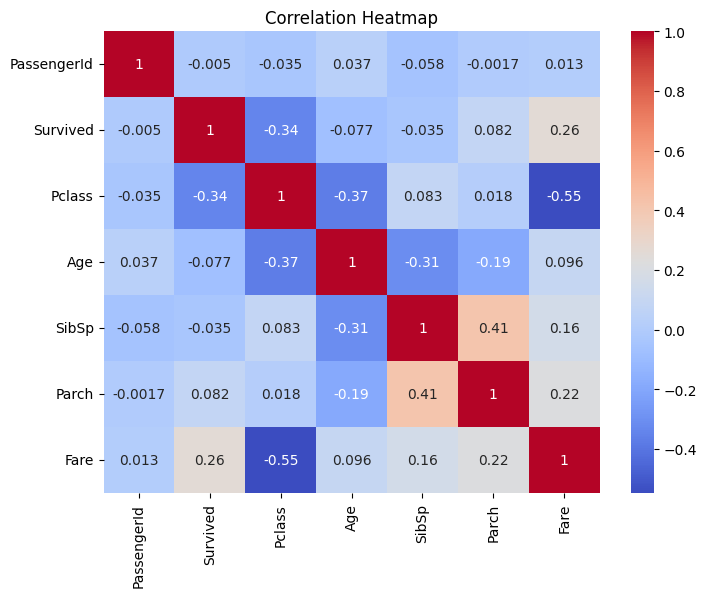

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Passenger class and fare show a noticeable relationship with survival, while age has a weaker correlation.

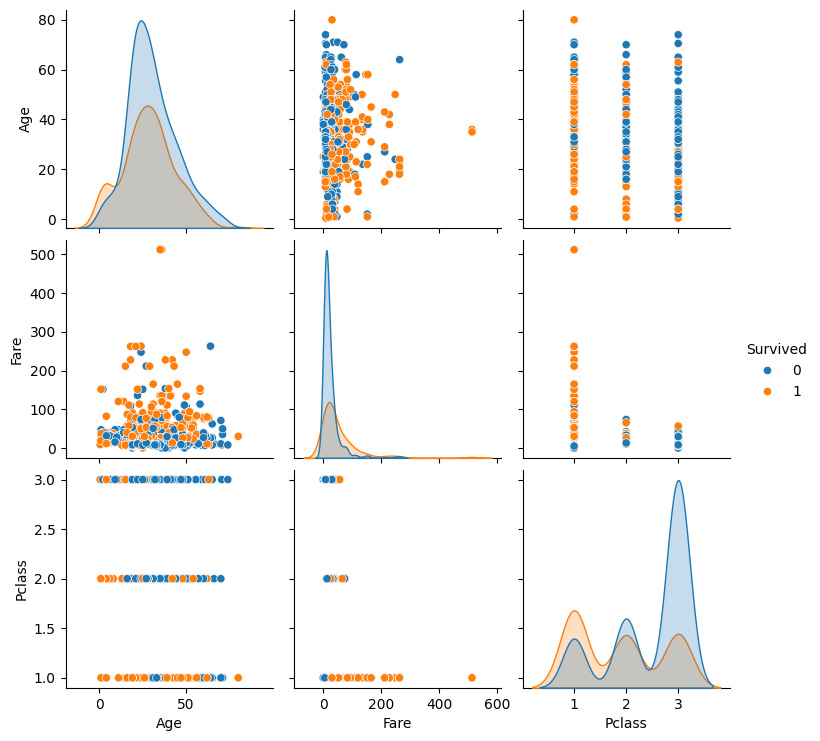

In [26]:
sns.pairplot(
    df[
        ["Survived","Age","Fare","Pclass"]
    ].dropna(),
    hue="Survived"
)

plt.show()

Fare and passenger class appear related, while age shows weaker relationships with other variables.

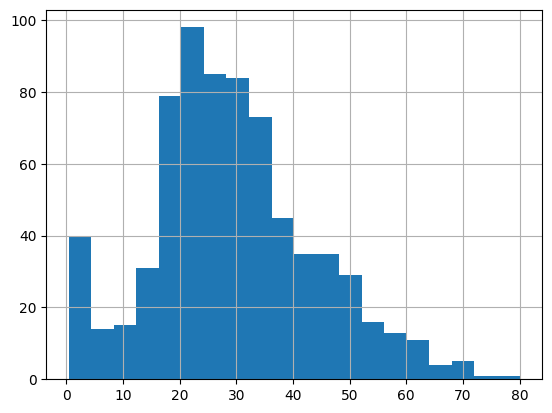

In [29]:
df['Age'].hist(bins=20)
plt.show()

Most passengers were between 20 and 40 years old, with fewer elderly passengers.

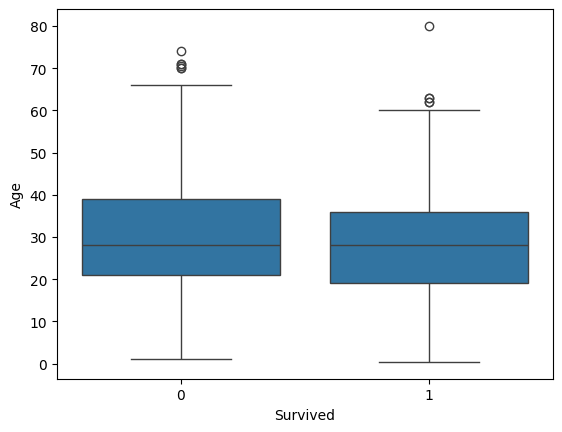

In [30]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.show()

FINAL SUMMARY OF FINDINGS:
1. The Titanic dataset contains passenger demographic and travel information with some missing values.
2. Female passengers had a significantly higher survival rate than male passengers.
3. First-class passengers were more likely to survive than second- and third-class passengers.
4. Most passengers were between 20 and 40 years old.
5. Ticket fares were highly skewed, with a small number of passengers paying premium fares.
6. Passenger class and fare had a stronger influence on survival than age.
7. Gender was one of the most important factors affecting passenger survival.
8. Overall, passenger class, gender, and fare were the key factors associated with survival on the Titanic.